# 6 - Individual Variability

This notebook analyzes individual differences in ESM response patterns and label variability.

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import get_data_root, COLORS, WAVE_KEYS, WAVE_TO_DIR, set_paper_style

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [ ]:
# ── Data loading helpers ─────────────────────────────────────────────────────────────────────────────
from utils import (
    load_wave_esm_userinfo,
    normalize_label_series,
    SHARED_LABELS,
    load_df_X_combined,
)

# ── Combined sensor data ───────────────────────────────────────────────────────────────────────────────────────
df_X_combined = load_df_X_combined(DATA_ROOT)
if not df_X_combined.empty:
    _meta_cols_s6 = {"META#dataset", "PIF#participantID", "PIF#stress_label",
                     "PIF#time_offset", "PIF#timestamp", "__src"}
    numeric_common_s6 = [
        c for c in (set(df_X_combined.columns) - _meta_cols_s6)
        if df_X_combined[c].dtype in ["float64", "int64", "float32", "int32"]
    ]
    print(f"Sensor data loaded: {len(df_X_combined)} rows, {len(numeric_common_s6)} numeric features")
else:
    numeric_common_s6 = []

Sensor data loaded: 52525 rows, 4931 numeric features


## Data processing

In [ ]:
esm_by_wave, _, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=False,
    include_study_day=True,
)

## Visuals

---
### Individual Variability: Cross-User Shift Magnitude Within Each Wave (Helper)

In [6]:
# Cross-user shift magnitude decomposition within each wave
def variance_components(label: str) -> tuple[float, float, float]:
    if esm_all.empty or label not in esm_all.columns:
        return np.nan, np.nan, np.nan
    sub = esm_all[["Wave", "Pcode", label]].dropna().copy()
    if sub.empty:
        return np.nan, np.nan, np.nan
    sub[label] = normalize_label_series(sub[label])
    grand_mean = sub[label].mean()
    total_var  = sub[label].var()
    if pd.isna(total_var) or total_var == 0:
        return np.nan, np.nan, np.nan
    wave_means = (
        sub.groupby("Wave")[label]
           .mean()
           .reset_index()
           .rename(columns={label: "wave_mean"})
    )
    person_means = (
        sub.groupby(["Wave", "Pcode"])[label]
           .mean()
           .reset_index()
           .rename(columns={label: "person_mean"})
    )
    sub = sub.merge(wave_means, on="Wave", how="left")
    sub = sub.merge(person_means, on=["Wave", "Pcode"], how="left")
    between_wave   = (sub["wave_mean"] - grand_mean).pow(2).mean()
    between_person = (sub["person_mean"] - sub["wave_mean"]).pow(2).mean()
    within_person  = max(0.0, total_var - between_wave - between_person)
    total = between_wave + between_person + within_person
    return within_person / total, between_person / total, between_wave / total

### Variance decomposition by person/day

This bar chart provides a direct cross-wave comparison of effect size or prevalence for the target metric.


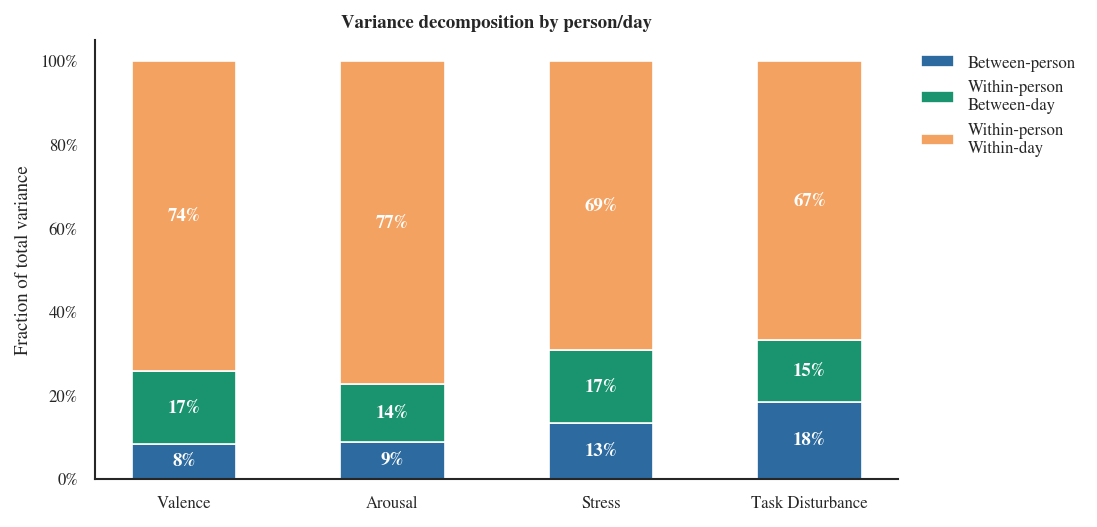

In [ ]:
results = []

for label in SHARED_LABELS:
    if esm_all.empty or label not in esm_all.columns:
        continue
    df = esm_all[["Pcode", "study_day", label]].dropna()

    grand_mean = df[label].mean()
    person_means = df.groupby("Pcode")[label].mean()

    # Between-person SS
    ss_between = sum(
        len(df[df["Pcode"] == p]) * (pm - grand_mean) ** 2
        for p, pm in person_means.items()
    )

    # Within-person between-day SS
    day_means = df.groupby(["Pcode", "study_day"])[label].mean().reset_index()
    day_means = day_means.merge(
        person_means.rename("pmean"), left_on="Pcode", right_index=True
    )
    ss_wpbd = (
        df.groupby(["Pcode", "study_day"])[label]
            .count()
            .reset_index(name="n")
            .merge(day_means, on=["Pcode", "study_day"])
    )
    ss_wpbd = (ss_wpbd["n"] * (ss_wpbd[label] - ss_wpbd["pmean"]) ** 2).sum()

    # Residual (within-person within-day)
    day_means_map = day_means.set_index(["Pcode", "study_day"])[label]
    df2 = df.copy()
    df2["day_mean"] = [day_means_map.get((r.Pcode, r.study_day), np.nan)
                        for _, r in df2.iterrows()]
    ss_resid = ((df2[label] - df2["day_mean"]) ** 2).sum()

    total = ss_between + ss_wpbd + ss_resid
    if total == 0:
        continue

    results.append({
        "label": label,
        "Between-person": ss_between / total,
        "Within-person\nBetween-day": ss_wpbd / total,
        "Within-person\nWithin-day": ss_resid / total,
    })

df_res = pd.DataFrame(results).set_index("label")
comp_colors = ["#2D6A9F", "#1A936F", "#F4A261"]

fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)
bottom = np.zeros(len(df_res))
for col, color in zip(df_res.columns, comp_colors):
    vals = df_res[col].values
    bars = ax.bar(df_res.index, vals, bottom=bottom,
                    color=color, label=col, edgecolor="white", width=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f"{val:.0%}",
                    ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    bottom += vals

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Fraction of total variance")
ax.set_title("Variance decomposition by person/day", fontweight="bold", fontsize=9)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.show()

### Intra-Class Correlation per Label (all waves pooled)

This bar chart provides a direct cross-wave comparison of effect size or prevalence for the target metric.


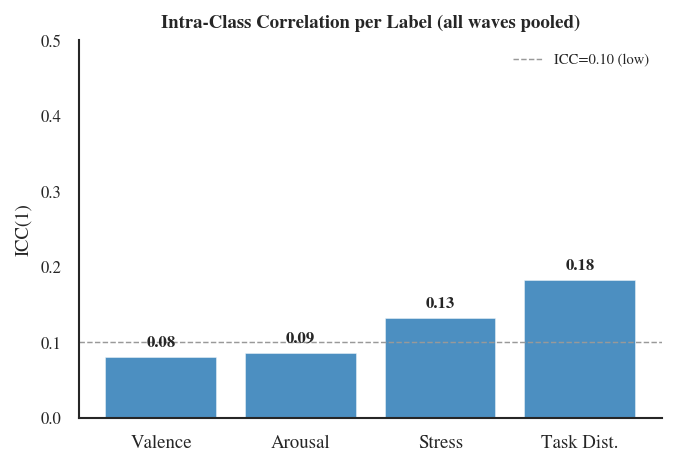

In [8]:
icc_vals = []
for lbl in SHARED_LABELS:
    if lbl not in esm_all.columns:
        icc_vals.append(np.nan)
        continue
    sub = esm_all[["Pcode", lbl]].dropna().copy()
    sub[lbl] = normalize_label_series(sub[lbl])
    counts = sub.groupby("Pcode").size()
    valid = counts[counts >= 2].index
    sub = sub[sub["Pcode"].isin(valid)]
    if sub["Pcode"].nunique() < 2:
        icc_vals.append(np.nan)
        continue
    grand_mean = sub[lbl].mean()
    person_means = sub.groupby("Pcode")[lbl].mean()
    person_counts = sub.groupby("Pcode").size()
    k0 = person_counts.mean()
    ms_between = ((person_means - grand_mean) ** 2 * person_counts).sum() / (sub["Pcode"].nunique() - 1)
    ss_within = sum(((sub[sub["Pcode"] == p][lbl] - person_means[p]) ** 2).sum() for p in person_means.index)
    n_total = len(sub)
    n_groups = sub["Pcode"].nunique()
    ms_within = ss_within / (n_total - n_groups) if (n_total - n_groups) > 0 else np.nan
    if np.isnan(ms_within) or ms_within == 0:
        icc_vals.append(np.nan)
        continue
    icc = (ms_between - ms_within) / (ms_between + (k0 - 1) * ms_within)
    icc_vals.append(max(0.0, icc))

fig, ax = plt.subplots(figsize=(4.4, 3.0), constrained_layout=True)
x = np.arange(len(SHARED_LABELS))
bars = ax.bar(x, icc_vals, color="#2C7BB6", alpha=0.85, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, icc_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["Valence", "Arousal", "Stress", "Task Dist."], fontsize=9)
ax.set_ylabel("ICC(1)")
max_val = max([v for v in icc_vals if not np.isnan(v)], default=0.5)
ax.set_ylim(0, max(0.5, max_val + 0.1))
ax.set_title("Intra-Class Correlation per Label (all waves pooled)", fontweight="bold", fontsize=9)
ax.axhline(0.1, color="0.6", ls="--", lw=0.7, label="ICC=0.10 (low)")
ax.legend(fontsize=7, frameon=False)
plt.show()

### Representative Four-Week Stress Trajectories

This plot highlights representative user-level stress trajectories over the four-week window.


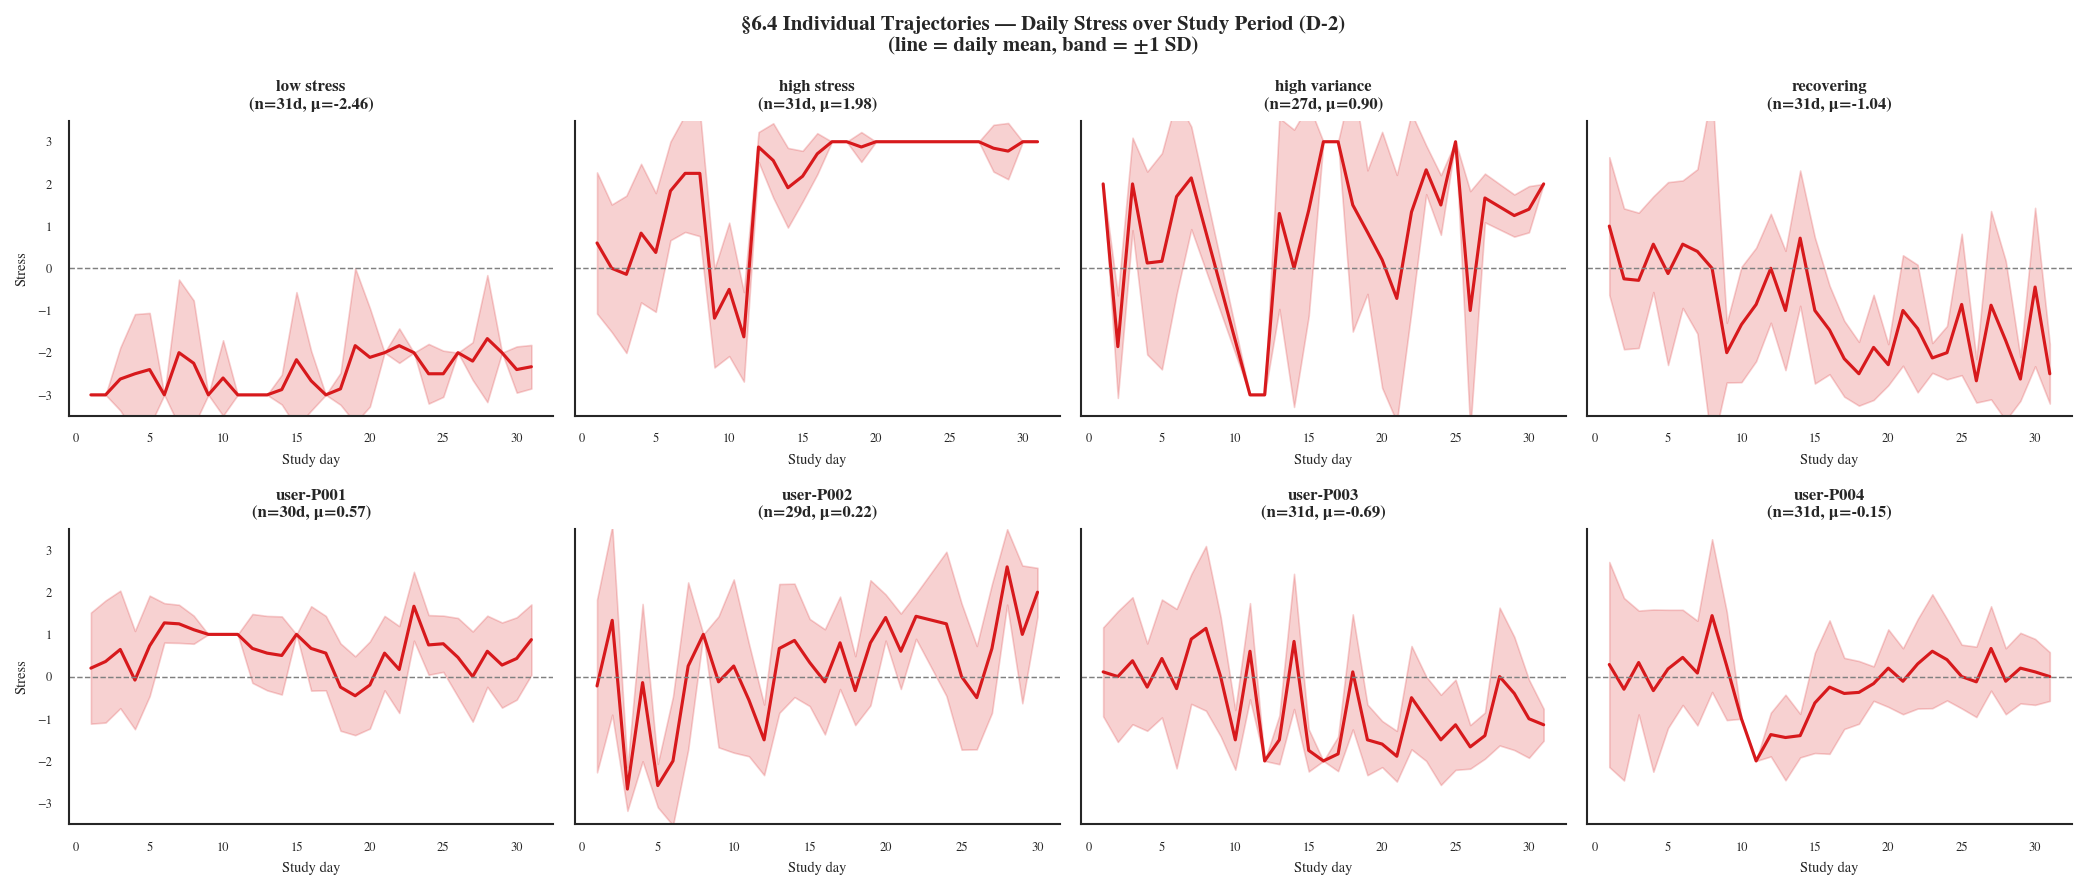

In [9]:
# ── Visual Q: Individual 4-week affective trajectories ───────────────────────
_stress_col_q = "Stress"

# Prefer longer-protocol waves (D-2, D-3) for 4-week data
# Use esm_all (has study_day) filtered by wave rather than esm_by_wave
_traj_waves = ["D-2", "D-3", "D-1"]
_traj_data = None
for _wk_q in _traj_waves:
    _df_q = esm_all[esm_all["Wave"] == _wk_q].copy()
    if _df_q.empty or _stress_col_q not in _df_q.columns or "study_day" not in _df_q.columns:
        continue
    _df_q[_stress_col_q] = normalize_label_series(_df_q[_stress_col_q])
    _traj_data = _df_q
    _traj_wave_key = _wk_q
    break

if _traj_data is not None:
    # Select users with ≥ 14 days of data
    _day_counts = _traj_data.groupby("Pcode")["study_day"].nunique()
    _eligible = _day_counts[_day_counts >= 14].index.tolist()
    _stats_q = _traj_data[_traj_data["Pcode"].isin(_eligible)].groupby("Pcode")[_stress_col_q].agg(
        ["mean", "std", "count"]
    )
    _stats_q = _stats_q[_stats_q["count"] >= 20]

    # Compute first-half vs second-half mean for "recovering" archetype
    def _recovery_score(pcode):
        _d = _traj_data[_traj_data["Pcode"] == pcode][["study_day", _stress_col_q]].dropna()
        _mid = _d["study_day"].median()
        _early = _d[_d["study_day"] <= _mid][_stress_col_q].mean()
        _late = _d[_d["study_day"] > _mid][_stress_col_q].mean()
        return _early - _late   # positive = decreasing stress (recovering)

    _candidates = {}
    _sorted_mean = _stats_q["mean"].sort_values()

    # Consistently low: bottom quartile of mean
    _low_q = _sorted_mean.quantile(0.25)
    _low_cands = _sorted_mean[_sorted_mean <= _low_q].index
    if len(_low_cands) > 0:
        _candidates["low stress"] = _low_cands[0]

    # Consistently high: top quartile
    _hi_q = _sorted_mean.quantile(0.75)
    _hi_cands = _sorted_mean[_sorted_mean >= _hi_q].index
    if len(_hi_cands) > 0:
        _candidates["high stress"] = _hi_cands[-1]

    # High variance
    _var_sorted = _stats_q["std"].sort_values(ascending=False)
    for _p in _var_sorted.index:
        if _p not in _candidates.values():
            _candidates["high variance"] = _p
            break

    # Recovering (high→low)
    _rec_scores = {p: _recovery_score(p) for p in _stats_q.index if p not in _candidates.values()}
    if _rec_scores:
        _best_rec = max(_rec_scores, key=_rec_scores.get)
        if _rec_scores[_best_rec] > 0.2:
            _candidates["recovering"] = _best_rec

    # Additional diverse users to fill up to 8 panels
    for _p in _stats_q.index:
        if len(_candidates) >= 8:
            break
        if _p not in _candidates.values():
            _candidates[f"user-{_p}"] = _p

    _n_panels = len(_candidates)
    if _n_panels == 0:
        print(f"Visual Q: no users with ≥ 14 days found in {_traj_wave_key}.")
    else:
        _ncols = 4
        _nrows = (_n_panels + _ncols - 1) // _ncols
        fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.5 * _ncols, 3 * _nrows),
                                  sharey=True)
        axes = np.array(axes).flat

        _wave_color_q = COLORS.get(_traj_wave_key, "#555555")

        for ax, (archetype, pcode) in zip(axes, _candidates.items()):
            _user_df = _traj_data[_traj_data["Pcode"] == pcode].groupby("study_day")[_stress_col_q].agg(
                ["mean", "std"]
            )
            _days = _user_df.index.values
            _means = _user_df["mean"].values
            _stds = _user_df["std"].fillna(0).values
            ax.plot(_days, _means, color=_wave_color_q, lw=1.5)
            ax.fill_between(_days, _means - _stds, _means + _stds,
                            alpha=0.2, color=_wave_color_q)
            ax.axhline(0, color="grey", lw=0.7, ls="--")
            ax.set_ylim(-3.5, 3.5)
            ax.set_title(f"{archetype}\n(n={len(_days)}d, μ={_means.mean():.2f})",
                         fontsize=8, fontweight="bold")
            ax.set_xlabel("Study day", fontsize=7)
            if ax.get_subplotspec().colspan.start == 0:
                ax.set_ylabel("Stress", fontsize=7)
            ax.tick_params(labelsize=6)
            ax.spines[["top", "right"]].set_visible(False)

        # Hide unused axes
        for ax in axes[len(_candidates):]:
            ax.set_visible(False)

        fig.suptitle(f"§6.4 Individual Trajectories — Daily Stress over Study Period ({_traj_wave_key})\n"
                     "(line = daily mean, band = ±1 SD)", fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("Skipped Visual Q: no ESM wave with study_day and Stress columns found.")


### Cross-User Shift Magnitude Within Each Wave

This 2×2 panel compares covariate, conditional, label, and concept shift magnitudes across waves.


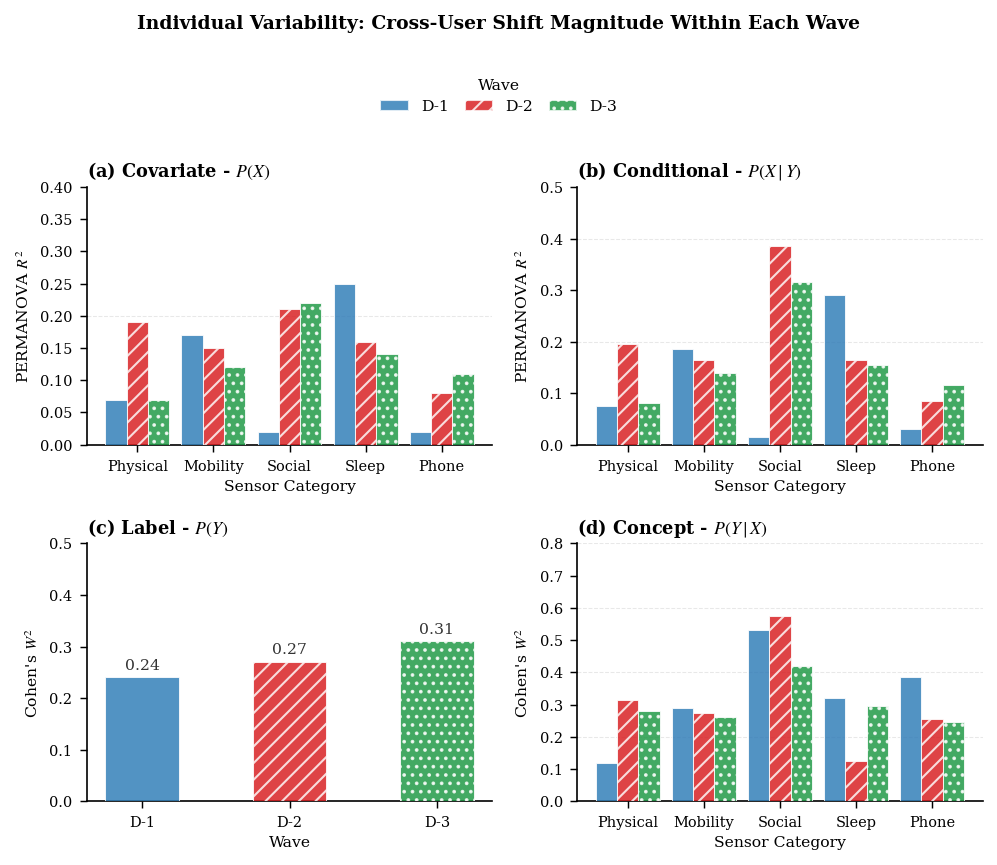

In [ ]:
# ── NeurIPS rcParams ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "mathtext.fontset": "stix",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "axes.titlepad": 6,
    "axes.grid": False,
    "xtick.major.size": 3.5,
    "xtick.major.width": 0.7,
    "ytick.major.size": 3.5,
    "ytick.major.width": 0.7,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.fontsize": 7.5,
    "legend.frameon": False,
    "figure.dpi": 150,
})

# Use notebook-level constants if available, else fall back.
_waves = WAVE_KEYS if "WAVE_KEYS" in globals() else ["D-1", "D-2", "D-3"]
_colors = COLORS if "COLORS" in globals() else {"D-1": "#2C7BB6", "D-2": "#D7191C", "D-3": "#1A9641"}
_cats = ["Physical", "Mobility", "Social", "Sleep", "Phone"]
_hatches = {"D-1": "", "D-2": "///", "D-3": "..."}

# ── Data: CrossShift Figure 6 and Table 4, D1/D2/D3 columns ──────────────────
covariate_r2 = {
    "Physical": {"D-1": 0.07,  "D-2": 0.19,  "D-3": 0.07},
    "Mobility": {"D-1": 0.17,  "D-2": 0.15,  "D-3": 0.12},
    "Social":   {"D-1": 0.02,  "D-2": 0.21,  "D-3": 0.22},
    "Sleep":    {"D-1": 0.25,  "D-2": 0.16,  "D-3": 0.14},
    "Phone":    {"D-1": 0.02,  "D-2": 0.08,  "D-3": 0.11},
}

conditional_r2 = {
    "Physical": {"D-1": 0.075, "D-2": 0.195, "D-3": 0.080},
    "Mobility": {"D-1": 0.185, "D-2": 0.165, "D-3": 0.140},
    "Social":   {"D-1": 0.015, "D-2": 0.385, "D-3": 0.315},
    "Sleep":    {"D-1": 0.290, "D-2": 0.165, "D-3": 0.155},
    "Phone":    {"D-1": 0.030, "D-2": 0.085, "D-3": 0.115},
}

label_w2 = {"D-1": 0.24, "D-2": 0.27, "D-3": 0.31}

concept_w2 = {
    "Physical": {"D-1": 0.120, "D-2": 0.315, "D-3": 0.280},
    "Mobility": {"D-1": 0.290, "D-2": 0.275, "D-3": 0.260},
    "Social":   {"D-1": 0.530, "D-2": 0.575, "D-3": 0.420},
    "Sleep":    {"D-1": 0.320, "D-2": 0.125, "D-3": 0.295},
    "Phone":    {"D-1": 0.385, "D-2": 0.255, "D-3": 0.245},
}

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.5))
fig.subplots_adjust(hspace=0.56, wspace=0.38)

ax_cov, ax_cond = axes[0, 0], axes[0, 1]
ax_lbl, ax_con = axes[1, 0], axes[1, 1]

bar_width = 0.28
x = np.arange(len(_cats))
x_lbl = np.arange(len(_waves))

# ── (a) Covariate: category bars ────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [covariate_r2[cat][wk] for cat in _cats]
    ax_cov.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.40, 0.2):
    ax_cov.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
# ax_cov.axhline(mean_cov, color="#666666", lw=0.9, ls=":", zorder=2)
ax_cov.set_ylim(0, 0.40)
ax_cov.set_ylabel(r"PERMANOVA $R^2$", fontsize=7.5)
ax_cov.set_title(r"(a) Covariate - $P(X)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_cov.set_xticks(x)
ax_cov.set_xticklabels(_cats, fontsize=7)
ax_cov.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_cov.tick_params(labelsize=7)
ax_cov.spines["left"].set_linewidth(0.8)

# ── (b) Conditional: category bars ──────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [conditional_r2[cat][wk] for cat in _cats]
    ax_cond.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.50, 0.2):
    ax_cond.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
ax_cond.set_ylim(0, 0.50)
ax_cond.set_ylabel(r"PERMANOVA $R^2$", fontsize=7.5)
ax_cond.set_title(r"(b) Conditional - $P(X \mid Y)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_cond.set_xticks(x)
ax_cond.set_xticklabels(_cats, fontsize=7)
ax_cond.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_cond.tick_params(labelsize=7)
ax_cond.spines["left"].set_linewidth(0.8)

# ── (c) Label: wave-only bars ───────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    ax_lbl.bar(
        x_lbl[w_idx], label_w2[wk],
        width=0.50, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
    ax_lbl.text(
        x_lbl[w_idx], label_w2[wk] + 0.01, f"{label_w2[wk]:.2f}",
        ha="center", va="bottom", fontsize=7.5, color="#333333",
    )
ax_lbl.set_ylim(0, 0.50)
ax_lbl.set_ylabel(r"Cohen's $W^2$", fontsize=7.5)
ax_lbl.set_title(r"(c) Label - $P(Y)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_lbl.set_xticks(x_lbl)
ax_lbl.set_xticklabels(_waves, fontsize=8)
ax_lbl.set_xlabel("Wave", fontsize=7.5, labelpad=3)
ax_lbl.tick_params(labelsize=7)
ax_lbl.spines["left"].set_linewidth(0.8)

# ── (d) Concept: category bars ──────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [concept_w2[cat][wk] for cat in _cats]
    ax_con.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.80, 0.2):
    ax_con.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
ax_con.set_ylim(0, 0.80)
ax_con.set_ylabel(r"Cohen's $W^2$", fontsize=7.5)
ax_con.set_title(r"(d) Concept - $P(Y \mid X)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_con.set_xticks(x)
ax_con.set_xticklabels(_cats, fontsize=7)
ax_con.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_con.tick_params(labelsize=7)
ax_con.spines["left"].set_linewidth(0.8)

# ── Shared legend + title ───────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=_colors[w], hatch=_hatches[w], edgecolor="white", alpha=0.82, label=w)
    for w in _waves
]
fig.legend(
    handles=legend_handles,
    title="Wave",
    title_fontsize=7.5,
    fontsize=7.5,
    loc="upper center",
    ncol=len(_waves) + 1,
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    handlelength=1.8,
    columnspacing=1.0,
)

fig.suptitle(
    "Individual Variability: Cross-User Shift Magnitude Within Each Wave",
    fontsize=9,
    fontweight="bold",
    y=1.10,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()